   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.7 MB/s eta 0:00:00
Mounted at /content/drive
Drive montato: True
Trovati 4 file zip per 2018:
  Estraggo historical_data_2018Q1.zip ... OK (46 MB)
  Estraggo historical_data_2018Q2.zip ... OK (56 MB)
  Estraggo historical_data_2018Q3.zip ... OK (52 MB)
  Estraggo historical_data_2018Q4.zip ... OK (44 MB)
  🗓️  ANNO IN ELABORAZIONE: 2018
  📄 matched_path : /content/drive/MyDrive/thesis_data/output/matched_2018.csv
  📄 hmda_path    : /content/drive/MyDrive/thesis_data/hmda/2018_public_lar_csv.csv
  📄 freddie_txts :
       → /content/freddie_local/historical_data_2018Q1.txt
       → /content/freddie_local/historical_data_2018Q2.txt
       → /content/freddie_local/historical_data_2018Q3.txt
       → /content/freddie_local/historical_data_2018Q4.txt
  historical_data_2018Q1.txt: 296,816 righe  (46 MB)
  historical_data_2018Q2.txt: 364,502 righe  (56 MB)
  historical_data_2018Q3.txt: 336,669 righe  (52 MB)
  historical_data_2018Q4.txt

,variable,mean_matched,mean_freddie,diff_mean,p10_matched,p10_freddie,p90_matched,p90_freddie,ks_stat,ks_p,flag
0,credit_score,745.54,746.14,-0.60,674.0,681.0,802.0,801.0,0.0224,9.30e-15,⚠️ DIVERSE
1,original_ltv,66.86,76.11,-9.25,38.0,51.0,93.0,95.0,0.2900,0.00e+00,⚠️ DIVERSE
2,original_dti,35.29,35.89,-0.59,21.0,22.0,47.0,47.0,0.0252,3.73e-18,⚠️ DIVERSE


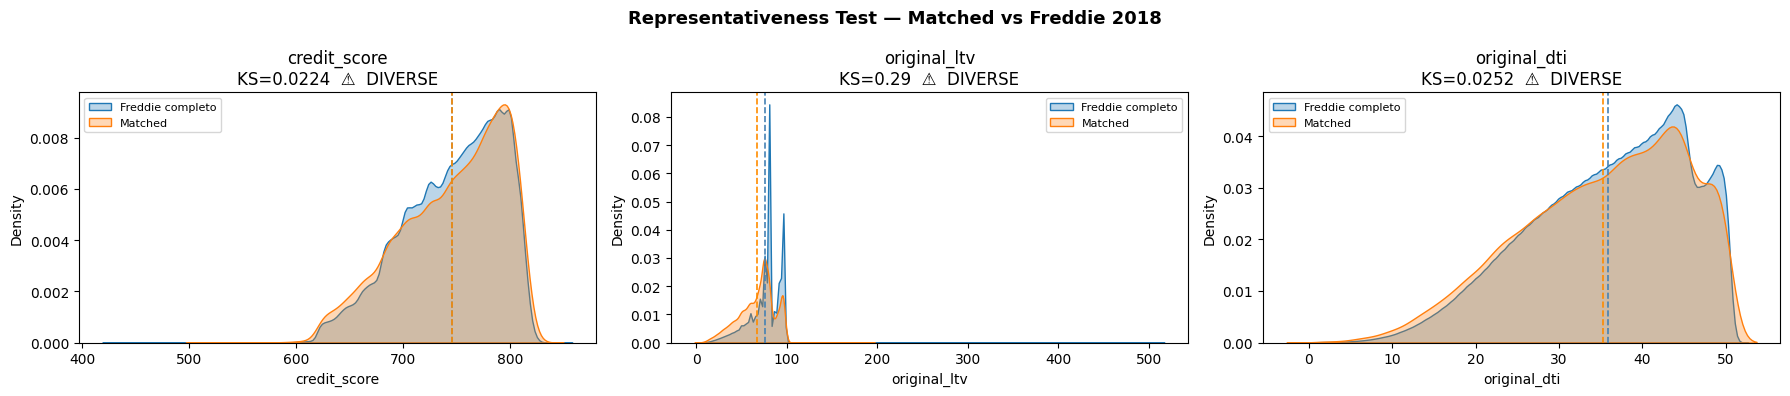

Grafico salvato: /content/drive/MyDrive/thesis_data/output/representativeness_2018.png

  BLOCCO 3 — CAMPIONE DI CONTROLLO HMDA (purchaser_type=3)
Campione HMDA di controllo: 815,893 righe

  BLOCCO 4 — DISTRIBUZIONE DEMOGRAFICA

Distribuzione etnica:
                                           HMDA (Freddie) %  Matched %  \
derived_race                                                             
White                                                 72.84      72.66   
Race Not Available                                    14.19      15.08   
Asian                                                  7.03       6.18   
Black or African American                              3.53       3.71   
Joint                                                  1.74       1.67   
American Indian or Alaska Native                       0.35       0.32   
Native Hawaiian or Other Pacific Islander              0.21       0.26   
2 or more minority races                               0.11       0.12   
Free For

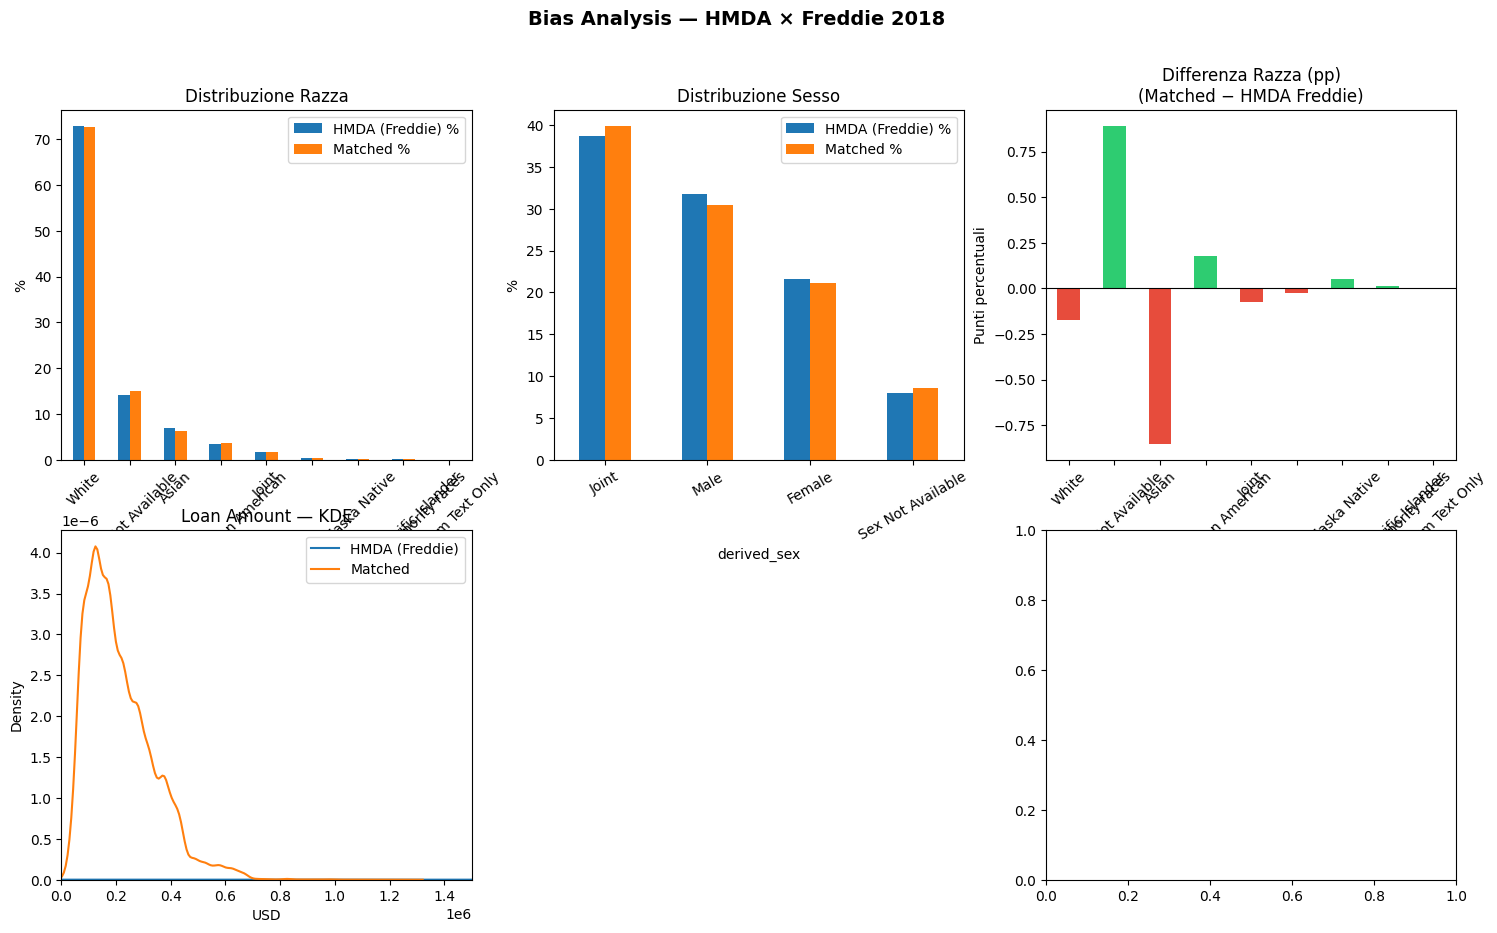

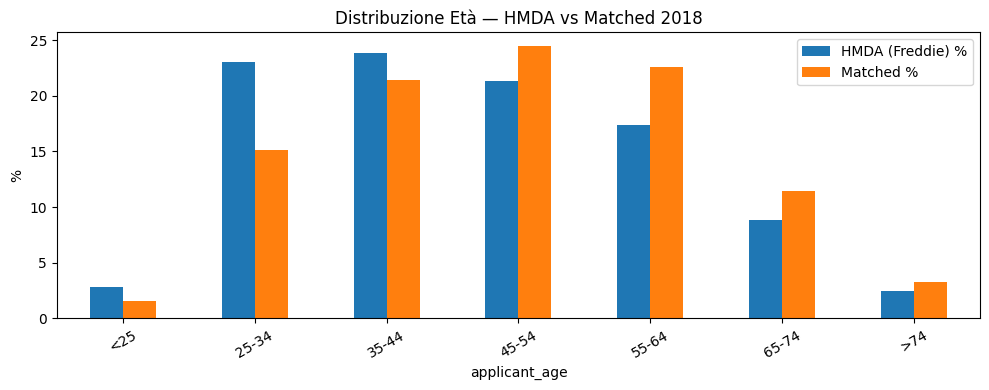

Grafico salvato: /content/drive/MyDrive/thesis_data/output/age_distribution_2018.png


<Figure size 640x480 with 0 Axes>

Grafico salvato: /content/drive/MyDrive/thesis_data/output/bias_analysis_2018.png


In [1]:
import os, gc, zipfile, shutil, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

!pip install pyarrow fastparquet -q

from google.colab import drive
drive.mount('/content/drive')

import os
print("Drive montato:", os.path.exists('/content/drive/MyDrive'))

# ─────────────────────────────────────────────
# COSTANTI GLOBALI — adatta i percorsi al tuo Drive
# ─────────────────────────────────────────────
FREDDIE_DIR   = "/content/drive/MyDrive/thesis_data/freddie"
FREDDIE_LOCAL = "/content/freddie_local"
HMDA_DIR      = "/content/drive/MyDrive/thesis_data/hmda"
OUTPUT_DIR    = "/content/drive/MyDrive/thesis_data/output"
os.makedirs(FREDDIE_LOCAL, exist_ok=True)
os.makedirs(OUTPUT_DIR,    exist_ok=True)

FREDDIE_ORIG_COLS = [
    "credit_score", "first_payment_date", "first_time_homebuyer_flag",
    "maturity_date", "msa", "mi_pct", "num_units", "occupancy_status",
    "original_cltv", "original_dti", "original_upb", "original_ltv",
    "original_interest_rate", "channel", "prepayment_penalty_flag",
    "amortization_type", "property_state", "property_type",
    "postal_code", "loan_sequence_number", "loan_purpose",
    "original_loan_term", "number_of_borrowers", "seller_name",
    "servicer_name", "super_conforming_flag", "pre_relief_refinance_seq_num",
    "program_indicator", "relief_refinance_indicator",
    "property_valuation_method", "io_indicator", "mortgage_insurance_cancellation"
]

MATCH_KEYS = ["state_code", "msa", "loan_amount_r",
              "loan_term", "num_units", "occupancy_type", "loan_purpose"]

FREDDIE_OCC_MAP     = {"P": 1, "S": 2, "I": 3}
FREDDIE_PURPOSE_MAP = {"P": 1, "C": 2, "N": 3, "R": 3, "U": 4}


# ─────────────────────────────────────────────
# 1. UNZIP
# ─────────────────────────────────────────────
def unzip_freddie_year(year: int) -> list:
    zip_pattern_sub  = os.path.join(FREDDIE_DIR, f"historical_data_{year}",
                                    f"historical_data_{year}Q*.zip")
    zip_pattern_flat = os.path.join(FREDDIE_DIR, f"historical_data_{year}Q*.zip")
    zip_files = glob.glob(zip_pattern_sub) or glob.glob(zip_pattern_flat)

    if not zip_files:
        raise FileNotFoundError(
            f"\nNessun file zip trovato per {year}.\n"
            f"Pattern cercati:\n  {zip_pattern_sub}\n  {zip_pattern_flat}"
        )

    print(f"Trovati {len(zip_files)} file zip per {year}:")
    extracted_txts = []

    for zpath in sorted(zip_files):
        zname    = os.path.basename(zpath)
        qname    = zname.replace(".zip", "")
        txt_dest = os.path.join(FREDDIE_LOCAL, f"{qname}.txt")

        if os.path.exists(txt_dest):
            size_mb = os.path.getsize(txt_dest) / 1e6
            print(f"  {zname} → già estratto ({size_mb:.0f} MB), skip")
            extracted_txts.append(txt_dest)
            continue

        print(f"  Estraggo {zname} ...", end=" ", flush=True)
        with zipfile.ZipFile(zpath, "r") as z:
            contents   = z.namelist()
            orig_files = [f for f in contents
                          if "time" not in f.lower() and f.endswith(".txt")]
            if not orig_files:
                print(f"\n  ATTENZIONE: nessun file origination in {zname}")
                print(f"  Contenuto: {contents}")
                continue
            with z.open(orig_files[0]) as src, open(txt_dest, "wb") as dst:
                shutil.copyfileobj(src, dst)

        size_mb = os.path.getsize(txt_dest) / 1e6
        print(f"OK ({size_mb:.0f} MB)")
        extracted_txts.append(txt_dest)

    return sorted(extracted_txts)


# ─────────────────────────────────────────────
# 2. LOAD & PREPARE
# ─────────────────────────────────────────────
def load_and_prepare_freddie(txt_files: list, year: int) -> pd.DataFrame:
    if not txt_files:
        raise ValueError("Nessun file .txt da caricare.")

    frames = []
    for f in txt_files:
        df = pd.read_csv(
            f, sep="|", header=None,
            names=FREDDIE_ORIG_COLS, dtype=str, low_memory=False,
        )
        print(f"  {os.path.basename(f)}: {len(df):,} righe  "
              f"({os.path.getsize(f)/1e6:.0f} MB)")
        frames.append(df)

    freddie = pd.concat(frames, ignore_index=True)
    del frames; gc.collect()
    print(f"Totale caricato: {len(freddie):,} righe")

    freddie["occupancy_status_orig"] = freddie["occupancy_status"].copy()
    freddie["loan_purpose_orig"]     = freddie["loan_purpose"].copy()

    freddie["occupancy_type"] = freddie["occupancy_status"].map(FREDDIE_OCC_MAP)
    freddie["loan_purpose"]   = freddie["loan_purpose"].map(FREDDIE_PURPOSE_MAP)

    freddie.rename(columns={
        "property_state":         "state_code",
        "original_upb":           "loan_amount_r",
        "original_interest_rate": "interest_rate",
        "original_loan_term":     "loan_term",
    }, inplace=True)

    for col in ["loan_amount_r", "interest_rate", "loan_term", "num_units",
                "original_ltv", "original_cltv", "original_dti",
                "credit_score", "mi_pct"]:
        if col in freddie.columns:
            freddie[col] = pd.to_numeric(freddie[col], errors="coerce")

    freddie["msa"]        = freddie["msa"].str.strip().fillna("")
    freddie["state_code"] = freddie["state_code"].str.strip()

    before = len(freddie)
    existing_keys = [k for k in MATCH_KEYS if k in freddie.columns]
    freddie.dropna(subset=existing_keys, inplace=True)
    print(f"Dopo dropna chiavi: {len(freddie):,} righe "
          f"(rimossi {before - len(freddie):,})")

    ram_mb = freddie.memory_usage(deep=True).sum() / 1e6
    print(f"RAM Freddie: {ram_mb:.0f} MB")
    return freddie


# ─────────────────────────────────────────────
# 3. FIND HMDA FILE
# ─────────────────────────────────────────────
def find_hmda_file(year: int) -> str:
    candidates = [
        os.path.join(HMDA_DIR, f"hmda_{year}.csv"),
        os.path.join(HMDA_DIR, f"{year}_public_lar.csv"),
        os.path.join(HMDA_DIR, f"hmda_{year}_nationwide_all-records_labels.csv"),
        os.path.join(HMDA_DIR, f"hmda_{year}_nationwide_all-records_codes.csv"),
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    found = glob.glob(os.path.join(HMDA_DIR, f"*{year}*.csv"))
    if found:
        return found[0]
    raise FileNotFoundError(
        f"\nNessun file HMDA trovato per {year} in '{HMDA_DIR}'."
    )


# ─────────────────────────────────────────────
# 4. RUN EVALUATION  (nessuna variabile globale)
# ─────────────────────────────────────────────
def run_evaluation(year: int):

    CHUNK_SIZE   = 200_000
    MAX_HMDA_REF = 1_000_000

    # percorsi tutti derivati da `year` e dalle costanti globali
    matched_path = os.path.join(OUTPUT_DIR, f"matched_{year}.csv")
    hmda_path    = find_hmda_file(year)
    freddie_txts = unzip_freddie_year(year)

    print("=" * 65)
    print(f"  🗓️  ANNO IN ELABORAZIONE: {year}")
    print("=" * 65)
    print(f"  📄 matched_path : {matched_path}")
    print(f"  📄 hmda_path    : {hmda_path}")
    print(f"  📄 freddie_txts :")
    for f in freddie_txts:
        print(f"       → {f}")
    print("=" * 65)

    freddie_ready = load_and_prepare_freddie(freddie_txts, year)
    print(f"  📊 freddie_ready: {len(freddie_ready):,} righe × "
          f"{len(freddie_ready.columns)} colonne")
    print("=" * 65 + "\n")

    df = pd.read_csv(matched_path, low_memory=False)

    # ── BLOCCO 1 — File matchato ─────────────────────────────────
    print("=" * 65)
    print("  BLOCCO 1 — CARICAMENTO FILE MATCHATO")
    print("=" * 65)
    print(f"Righe   : {len(df):,}")
    print(f"Colonne : {len(df.columns)}")

    print("\n--- MATCH RATE ---")
    n_freddie = len(freddie_ready)
    n_matched = df["loan_sequence_number"].nunique()
    print(f"Freddie totali  : {n_freddie:,}")
    print(f"Freddie matchati: {n_matched:,}")
    print(f"Match rate      : {100 * n_matched / n_freddie:.2f}%")

    print("\n--- DUPLICATE CHECK ---")
    dup_loans = df.duplicated(subset=["loan_sequence_number"]).sum()
    print(f"Duplicate loan_sequence_number : {dup_loans:,}")
    existing_keys = [k for k in MATCH_KEYS if k in df.columns]
    if existing_keys:
        dup_keys = df.duplicated(subset=existing_keys).sum()
        print(f"Duplicate su match keys        : {dup_keys:,}")

    print("\n--- DEMOGRAPHIC COVERAGE ---")
    for col in ["derived_race", "derived_sex", "applicant_age"]:
        if col in df.columns:
            miss = df[col].isna().mean()
            print(f"{col:20s}: {miss*100:.2f}% missing")

    print("\n--- DISTRIBUZIONE VARIABILI CHIAVE (matched) ---")
    for col in ["loan_amount_r", "interest_rate", "loan_term"]:
        if col in df.columns:
            print(f"\n{col}:")
            print(df[col].describe().round(2))

    # ── BLOCCO 2 — Representativeness test ──────────────────────
    print("\n" + "=" * 65)
    print("  BLOCCO 2 — REPRESENTATIVENESS TEST (Matched vs Freddie)")
    print("=" * 65)

    FREDDIE_CHECK_COLS = ["credit_score", "original_ltv", "original_dti"]
    rep_rows = []

    for col in FREDDIE_CHECK_COLS:
        if col not in df.columns or col not in freddie_ready.columns:
            print(f"  {col}: colonna assente — saltata")
            continue

        m = pd.to_numeric(df[col],              errors="coerce").dropna()
        f = pd.to_numeric(freddie_ready[col],   errors="coerce").dropna()
        f = f[~f.isin([999, 9999])]
        m = m[~m.isin([999, 9999])]

        ks_stat, ks_p = ks_2samp(m, f)
        rep_rows.append({
            "variable":    col,
            "mean_matched": round(m.mean(), 2),
            "mean_freddie": round(f.mean(), 2),
            "diff_mean":    round(m.mean() - f.mean(), 2),
            "diff_pct":      round((m.mean() - f.mean()) / f.mean() * 100, 2),
            "p10_matched":  round(m.quantile(0.10), 2),
            "p10_freddie":  round(f.quantile(0.10), 2),
            "p90_matched":  round(m.quantile(0.90), 2),
            "p90_freddie":  round(f.quantile(0.90), 2),
            "ks_stat":      round(ks_stat, 4),
            "ks_p":         f"{ks_p:.2e}",
            "flag":         "⚠️  DIVERSE" if ks_p < 0.05 else "✅ simili",
        })

    rep_df = pd.DataFrame(rep_rows)
    print("\nConfronto Matched vs Freddie completo:")
    display(rep_df)

    if rep_rows:
        n_cols = len(rep_rows)
        fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 4))
        if n_cols == 1:
            axes = [axes]
        fig.suptitle(f"Representativeness Test — Matched vs Freddie {year}",
                     fontsize=13, fontweight="bold")

        for ax, row in zip(axes, rep_rows):
            col = row["variable"]
            m   = pd.to_numeric(df[col],            errors="coerce").dropna()
            f   = pd.to_numeric(freddie_ready[col], errors="coerce").dropna()
            f   = f[~f.isin([999, 9999])]
            m   = m[~m.isin([999, 9999])]
            sns.kdeplot(f, ax=ax, label="Freddie completo", fill=True, alpha=0.3)
            sns.kdeplot(m, ax=ax, label="Matched",          fill=True, alpha=0.3)
            ax.axvline(f.mean(), color="steelblue",  linestyle="--", linewidth=1.2)
            ax.axvline(m.mean(), color="darkorange", linestyle="--", linewidth=1.2)
            ax.set_title(f"{col}\nKS={row['ks_stat']}  {row['flag']}")
            ax.legend(fontsize=8)

        plt.tight_layout()
        rep_path = os.path.join(OUTPUT_DIR, f"representativeness_{year}.png")
        plt.savefig(rep_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Grafico salvato: {rep_path}")

    # ── BLOCCO 3 — Campione di controllo HMDA ───────────────────
    print("\n" + "=" * 65)
    print("  BLOCCO 3 — CAMPIONE DI CONTROLLO HMDA (purchaser_type=3)")
    print("=" * 65)

    REF_COLS    = ["derived_race", "derived_sex", "loan_amount", "income", "applicant_age"]
    chunks_ref  = []
    rows_so_far = 0

    for chunk in pd.read_csv(hmda_path, dtype=str, chunksize=CHUNK_SIZE, low_memory=False):
        chunk.rename(columns=lambda c: c.replace("-", "_"), inplace=True)
        mask = (chunk["purchaser_type"] == "3") & (chunk["action_taken"] == "1")
        sub  = chunk.loc[mask, [c for c in REF_COLS if c in chunk.columns]]
        if not sub.empty:
            chunks_ref.append(sub)
            rows_so_far += len(sub)
        if rows_so_far >= MAX_HMDA_REF:
            break
        del chunk, sub; gc.collect()

    hmda_ref = pd.concat(chunks_ref, ignore_index=True)
    del chunks_ref; gc.collect()

    hmda_ref["loan_amount"] = pd.to_numeric(hmda_ref["loan_amount"], errors="coerce")
    hmda_ref["income"]      = pd.to_numeric(hmda_ref["income"],      errors="coerce")

    if "loan_amount" not in df.columns and "loan_amount_r" in df.columns:
        df["loan_amount"] = df["loan_amount_r"]

    print(f"Campione HMDA di controllo: {len(hmda_ref):,} righe")

    # ── BLOCCO 4 — Distribuzione demografica ────────────────────
    print("\n" + "=" * 65)
    print("  BLOCCO 4 — DISTRIBUZIONE DEMOGRAFICA")
    print("=" * 65)

    comp_race = comp_sex = comp_age = None

    if "derived_race" in hmda_ref.columns and "derived_race" in df.columns:
        comp_race = pd.DataFrame({
            "HMDA (Freddie) %": hmda_ref["derived_race"].value_counts(normalize=True) * 100,
            "Matched %":        df["derived_race"].value_counts(normalize=True) * 100,
        }).fillna(0)
        comp_race["Diff (pp)"] = comp_race["Matched %"] - comp_race["HMDA (Freddie) %"]
        print("\nDistribuzione etnica:")
        print(comp_race.round(2))

    if "derived_sex" in hmda_ref.columns and "derived_sex" in df.columns:
        comp_sex = pd.DataFrame({
            "HMDA (Freddie) %": hmda_ref["derived_sex"].value_counts(normalize=True) * 100,
            "Matched %":        df["derived_sex"].value_counts(normalize=True) * 100,
        }).fillna(0)
        comp_sex["Diff (pp)"] = comp_sex["Matched %"] - comp_sex["HMDA (Freddie) %"]
        print("\nDistribuzione sesso:")
        print(comp_sex.round(2))

    if "applicant_age" in hmda_ref.columns and "applicant_age" in df.columns:
        comp_age = pd.DataFrame({
            "HMDA (Freddie) %": hmda_ref["applicant_age"].value_counts(normalize=True) * 100,
            "Matched %":        df["applicant_age"].value_counts(normalize=True) * 100,
        }).fillna(0)
        comp_age["Diff (pp)"] = comp_age["Matched %"] - comp_age["HMDA (Freddie) %"]
        age_order = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
        comp_age  = comp_age.reindex([a for a in age_order if a in comp_age.index])
        print("\nDistribuzione età:")
        print(comp_age.round(2))

    # ── BLOCCO 5 — Test KS ───────────────────────────────────────
    print("\n" + "=" * 65)
    print("  BLOCCO 5 — TEST KS (P < 0.05 → distribuzioni diverse)")
    print("=" * 65)

    for col, label in [("loan_amount", "Loan Amount"), ("income", "Income")]:
        h = hmda_ref[col].dropna() if col in hmda_ref.columns else pd.Series(dtype=float)
        m = df[col].dropna()       if col in df.columns       else pd.Series(dtype=float)
        if h.empty or m.empty:
            print(f"{label:15s}: dati mancanti — saltato")
            continue
        ks, p = ks_2samp(h, m)
        print(f"{label:15s}: KS = {ks:.4f},  p = {p:.2e}  "
              f"→ {'⚠️  DIVERSE' if p < 0.05 else '✅ simili'}")

    print("\n--- Medie ---")
    stats = {}
    for col in ["loan_amount", "income"]:
        stats[col] = {
            "HMDA (Freddie)": round(hmda_ref[col].mean() if col in hmda_ref.columns else float("nan"), 2),
            "Matched":        round(df[col].mean()       if col in df.columns       else float("nan"), 2),
        }
    print(pd.DataFrame(stats).T)

    # ── BLOCCO 6 — Grafici bias ──────────────────────────────────
    print("\n" + "=" * 65)
    print("  BLOCCO 6 — VISUALIZZAZIONI BIAS")
    print("=" * 65)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Bias Analysis — HMDA × Freddie {year}",
                 fontsize=14, fontweight="bold")

    ax = axes[0, 0]
    if comp_race is not None:
        comp_race[["HMDA (Freddie) %", "Matched %"]].plot(kind="bar", ax=ax)
        ax.set_title("Distribuzione Razza"); ax.set_ylabel("%")
        ax.tick_params(axis="x", rotation=45)
    else:
        ax.set_visible(False)

    ax = axes[0, 1]
    if comp_sex is not None:
        comp_sex[["HMDA (Freddie) %", "Matched %"]].plot(kind="bar", ax=ax)
        ax.set_title("Distribuzione Sesso"); ax.set_ylabel("%")
        ax.tick_params(axis="x", rotation=30)
    else:
        ax.set_visible(False)

    ax = axes[0, 2]
    if comp_race is not None:
        colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in comp_race["Diff (pp)"]]
        comp_race["Diff (pp)"].plot(kind="bar", ax=ax, color=colors)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title("Differenza Razza (pp)\n(Matched − HMDA Freddie)")
        ax.set_ylabel("Punti percentuali"); ax.tick_params(axis="x", rotation=45)
    else:
        ax.set_visible(False)

    ax = axes[1, 0]
    if "loan_amount" in hmda_ref.columns and "loan_amount" in df.columns:
        sns.kdeplot(data=hmda_ref, x="loan_amount", ax=ax,
                    label="HMDA (Freddie)", common_norm=False)
        sns.kdeplot(data=df,       x="loan_amount", ax=ax,
                    label="Matched", common_norm=False)
        ax.set_xlim(0, 1_500_000); ax.set_title("Loan Amount — KDE")
        ax.set_xlabel("USD"); ax.legend()
    else:
        ax.set_visible(False)

    # (1,1) — grafico età separato, ax lasciato vuoto nella griglia principale
    axes[1, 1].set_visible(False)
    if comp_age is not None:
        fig_age, ax_age = plt.subplots(figsize=(10, 4))
        comp_age[["HMDA (Freddie) %", "Matched %"]].plot(kind="bar", ax=ax_age)
        ax_age.set_title(f"Distribuzione Età — HMDA vs Matched {year}")
        ax_age.set_ylabel("%"); ax_age.tick_params(axis="x", rotation=30)
        plt.tight_layout()
        age_path = os.path.join(OUTPUT_DIR, f"age_distribution_{year}.png")
        fig_age.savefig(age_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Grafico salvato: {age_path}")

    ax = axes[1, 2]
    if "income" in hmda_ref.columns and "income" in df.columns:
        sns.kdeplot(data=hmda_ref, x="income", ax=ax,
                    label="HMDA (Freddie)", common_norm=False)
        sns.kdeplot(data=df,       x="income", ax=ax,
                    label="Matched", common_norm=False)
        ax.set_xlim(0, 400); ax.set_title("Income — KDE")
        ax.set_xlabel("$000"); ax.legend()
    else:
        ax.set_visible(False)

    plt.tight_layout()
    bias_path = os.path.join(OUTPUT_DIR, f"bias_analysis_{year}.png")
    plt.savefig(bias_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Grafico salvato: {bias_path}")


# ─────────────────────────────────────────────
# ESECUZIONE
# ─────────────────────────────────────────────
run_evaluation(2018)

Trovati 4 file zip per 2019:
  Estraggo historical_data_2019Q1.zip ... OK (43 MB)
  Estraggo historical_data_2019Q2.zip ... OK (64 MB)
  Estraggo historical_data_2019Q3.zip ... OK (84 MB)
  Estraggo historical_data_2019Q4.zip ... OK (84 MB)
  🗓️  ANNO IN ELABORAZIONE: 2019
  📄 matched_path : /content/drive/MyDrive/thesis_data/output/matched_2019.csv
  📄 hmda_path    : /content/drive/MyDrive/thesis_data/hmda/2019_public_lar_csv.csv
  📄 freddie_txts :
       → /content/freddie_local/historical_data_2019Q1.txt
       → /content/freddie_local/historical_data_2019Q2.txt
       → /content/freddie_local/historical_data_2019Q3.txt
       → /content/freddie_local/historical_data_2019Q4.txt
  historical_data_2019Q1.txt: 279,861 righe  (43 MB)
  historical_data_2019Q2.txt: 413,821 righe  (64 MB)
  historical_data_2019Q3.txt: 542,237 righe  (84 MB)
  historical_data_2019Q4.txt: 545,225 righe  (84 MB)
Totale caricato: 1,781,144 righe
Dopo dropna chiavi: 1,781,144 righe (rimossi 0)
RAM Freddie: 2337

,variable,mean_matched,mean_freddie,diff_mean,p10_matched,p10_freddie,p90_matched,p90_freddie,ks_stat,ks_p,flag
0,credit_score,749.39,750.20,-0.81,681.0,687.0,802.0,801.0,0.0235,3.07e-24,⚠️ DIVERSE
1,original_ltv,67.98,75.65,-7.67,41.0,51.0,93.0,95.0,0.2437,0.00e+00,⚠️ DIVERSE
2,original_dti,34.82,35.19,-0.37,21.0,22.0,47.0,47.0,0.0203,3.36e-18,⚠️ DIVERSE


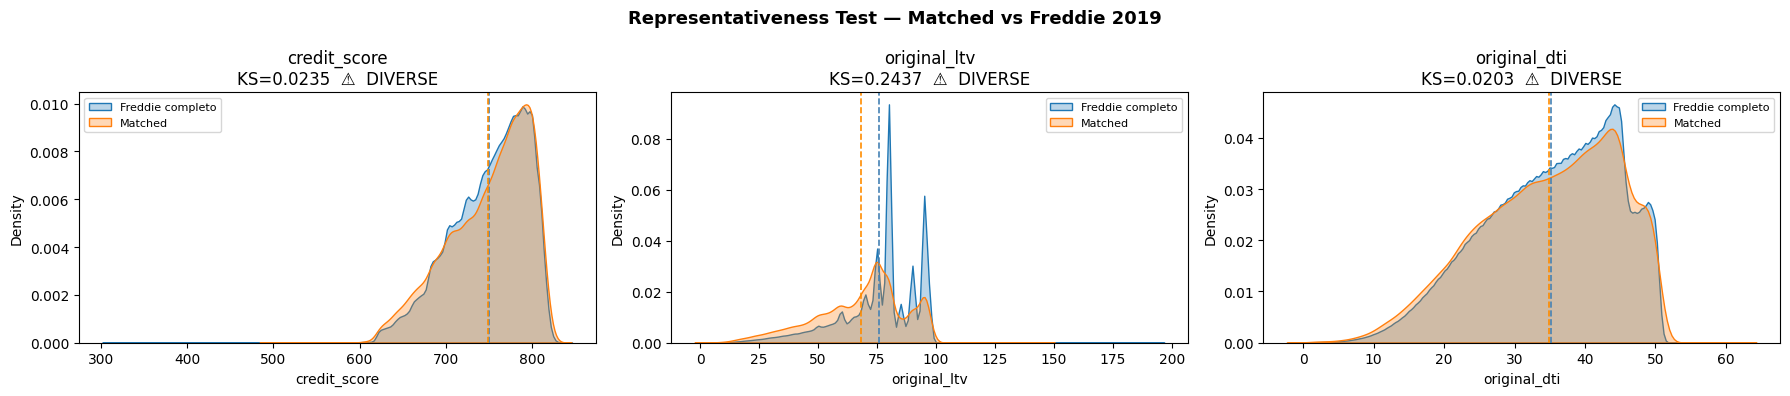

Grafico salvato: /content/drive/MyDrive/thesis_data/output/representativeness_2019.png

  BLOCCO 3 — CAMPIONE DI CONTROLLO HMDA (purchaser_type=3)
Campione HMDA di controllo: 1,000,483 righe

  BLOCCO 4 — DISTRIBUZIONE DEMOGRAFICA

Distribuzione etnica:
                                           HMDA (Freddie) %  Matched %  \
derived_race                                                             
White                                                 70.77      70.87   
Race Not Available                                    16.40      16.61   
Asian                                                  7.11       6.67   
Black or African American                              3.27       3.40   
Joint                                                  1.83       1.81   
American Indian or Alaska Native                       0.32       0.31   
Native Hawaiian or Other Pacific Islander              0.20       0.21   
2 or more minority races                               0.10       0.11   
Free F

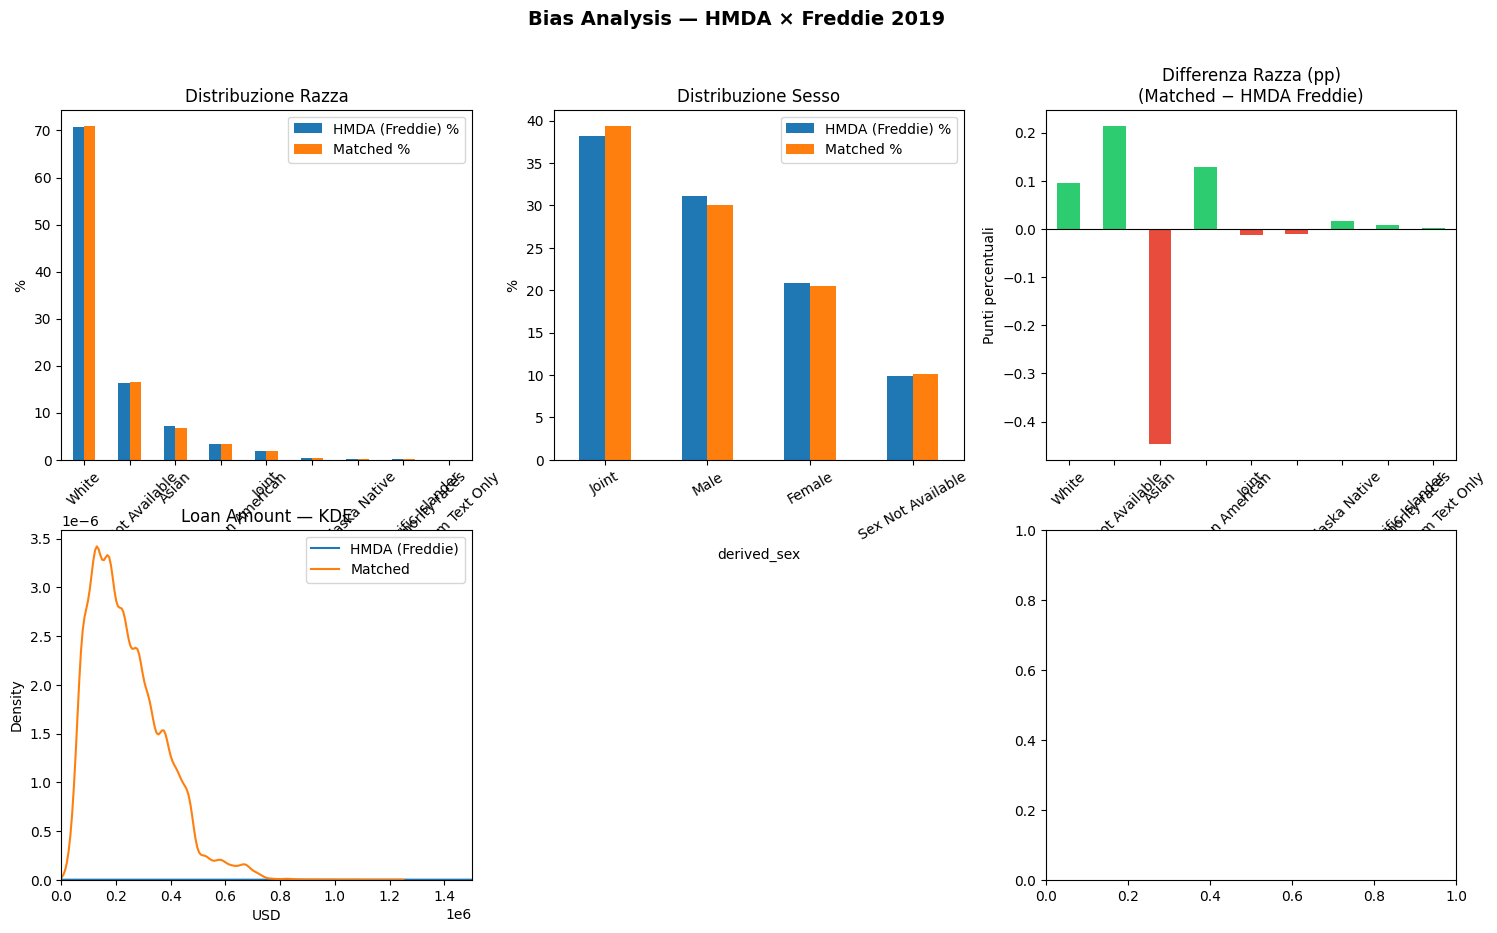

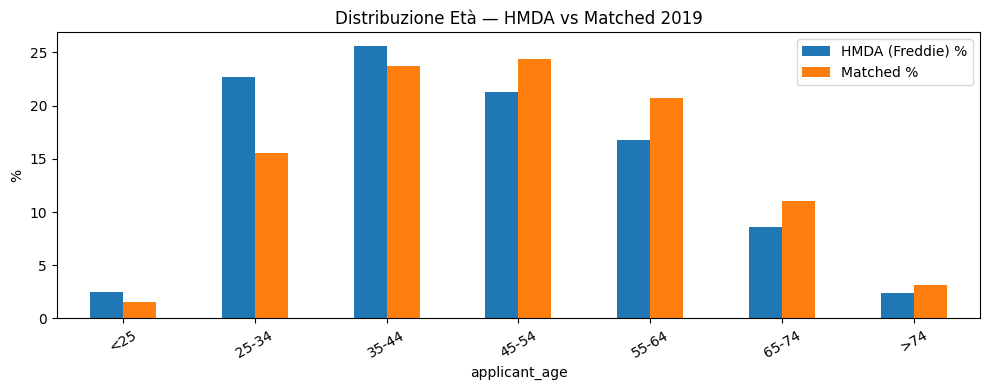

Grafico salvato: /content/drive/MyDrive/thesis_data/output/age_distribution_2019.png


<Figure size 640x480 with 0 Axes>

Grafico salvato: /content/drive/MyDrive/thesis_data/output/bias_analysis_2019.png


In [2]:
run_evaluation(2019)

Trovati 4 file zip per 2020:
  Estraggo historical_data_2020Q1.zip ... OK (80 MB)
  Estraggo historical_data_2020Q2.zip ... OK (138 MB)
  Estraggo historical_data_2020Q3.zip ... OK (179 MB)
  Estraggo historical_data_2020Q4.zip ... OK (195 MB)
  🗓️  ANNO IN ELABORAZIONE: 2020
  📄 matched_path : /content/drive/MyDrive/thesis_data/output/matched_2020.csv
  📄 hmda_path    : /content/drive/MyDrive/thesis_data/hmda/2020_lar_csv.csv
  📄 freddie_txts :
       → /content/freddie_local/historical_data_2020Q1.txt
       → /content/freddie_local/historical_data_2020Q2.txt
       → /content/freddie_local/historical_data_2020Q3.txt
       → /content/freddie_local/historical_data_2020Q4.txt
  historical_data_2020Q1.txt: 517,072 righe  (80 MB)
  historical_data_2020Q2.txt: 926,252 righe  (138 MB)
  historical_data_2020Q3.txt: 1,187,784 righe  (179 MB)
  historical_data_2020Q4.txt: 1,282,633 righe  (195 MB)
Totale caricato: 3,913,741 righe
Dopo dropna chiavi: 3,913,741 righe (rimossi 0)
RAM Freddie: 5

,variable,mean_matched,mean_freddie,diff_mean,p10_matched,p10_freddie,p90_matched,p90_freddie,ks_stat,ks_p,flag
0,credit_score,757.73,759.09,-1.36,693.0,698.0,806.0,805.0,0.0183,7.05e-25,⚠️ DIVERSE
1,original_ltv,65.46,70.29,-4.83,41.0,46.0,89.0,93.0,0.1494,0.00e+00,⚠️ DIVERSE
2,original_dti,33.50,33.13,0.37,19.0,20.0,46.0,45.0,0.0210,1.26e-32,⚠️ DIVERSE


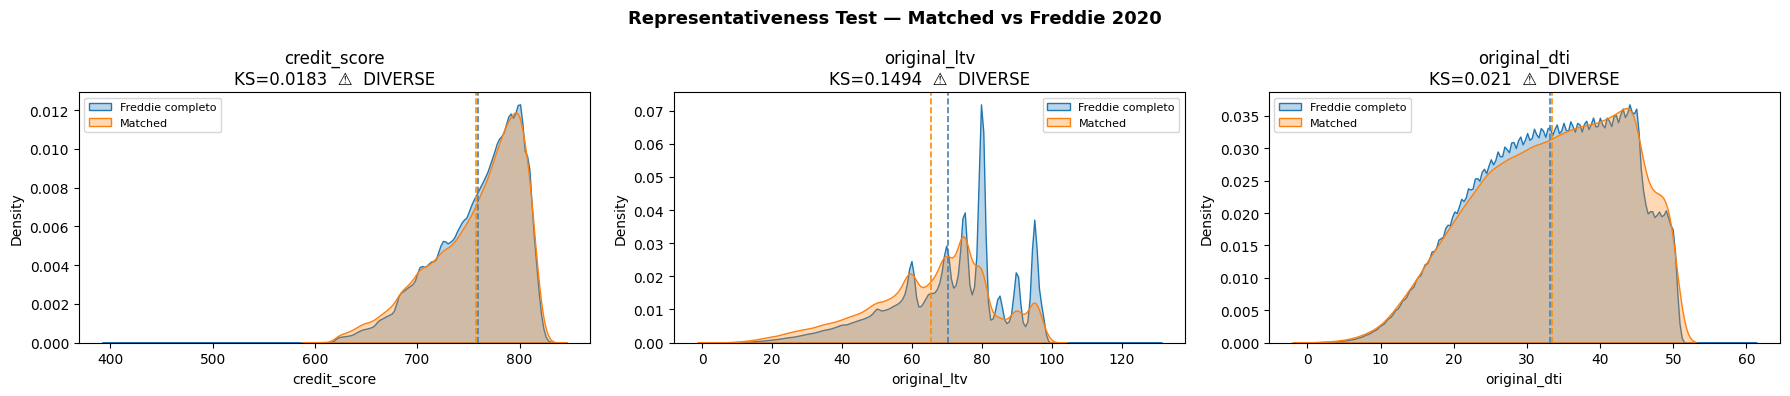

Grafico salvato: /content/drive/MyDrive/thesis_data/output/representativeness_2020.png

  BLOCCO 3 — CAMPIONE DI CONTROLLO HMDA (purchaser_type=3)
Campione HMDA di controllo: 1,004,459 righe

  BLOCCO 4 — DISTRIBUZIONE DEMOGRAFICA

Distribuzione etnica:
                                           HMDA (Freddie) %  Matched %  \
derived_race                                                             
White                                                 65.57      70.51   
Race Not Available                                    21.16      17.15   
Asian                                                  7.78       6.94   
Black or African American                              2.97       2.99   
Joint                                                  1.91       1.84   
American Indian or Alaska Native                       0.30       0.30   
Native Hawaiian or Other Pacific Islander              0.18       0.18   
2 or more minority races                               0.11       0.09   
Free F

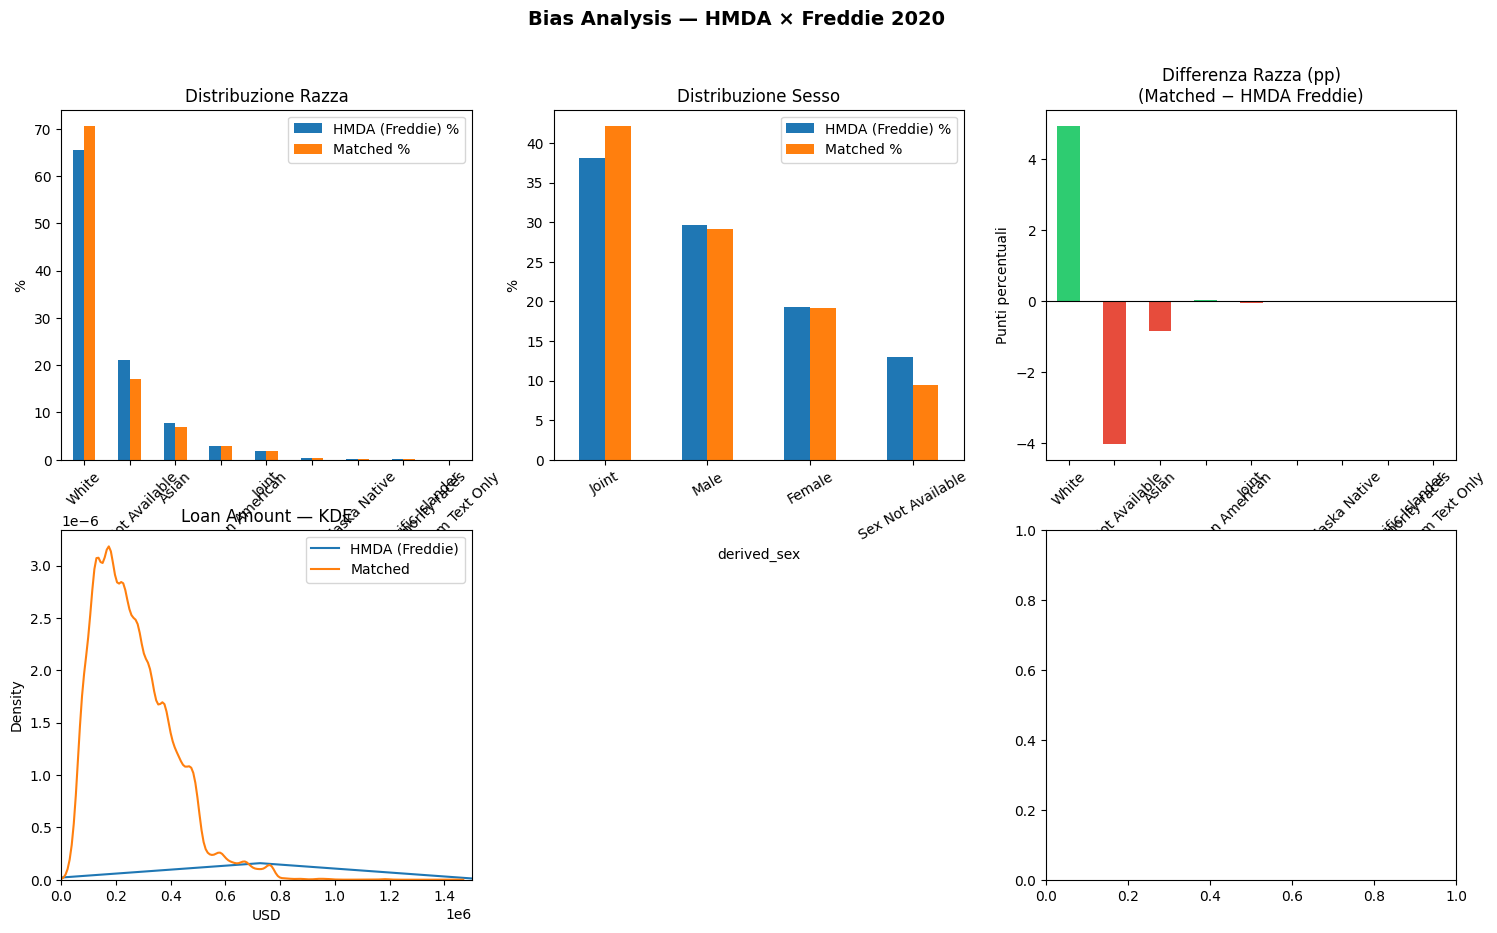

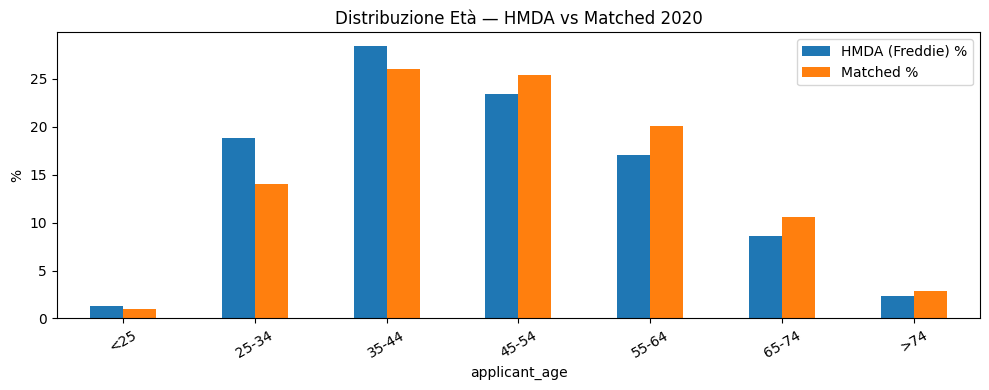

Grafico salvato: /content/drive/MyDrive/thesis_data/output/age_distribution_2020.png


<Figure size 640x480 with 0 Axes>

Grafico salvato: /content/drive/MyDrive/thesis_data/output/bias_analysis_2020.png


In [3]:
run_evaluation(2020)

Trovati 4 file zip per 2021:
  Estraggo historical_data_2021Q1.zip ... OK (186 MB)
  Estraggo historical_data_2021Q2.zip ... OK (148 MB)
  Estraggo historical_data_2021Q3.zip ... OK (161 MB)
  Estraggo historical_data_2021Q4.zip ... OK (134 MB)
  🗓️  ANNO IN ELABORAZIONE: 2021
  📄 matched_path : /content/drive/MyDrive/thesis_data/output/matched_2021.csv
  📄 hmda_path    : /content/drive/MyDrive/thesis_data/hmda/2021_public_lar.csv
  📄 freddie_txts :
       → /content/freddie_local/historical_data_2021Q1.txt
       → /content/freddie_local/historical_data_2021Q2.txt
       → /content/freddie_local/historical_data_2021Q3.txt
       → /content/freddie_local/historical_data_2021Q4.txt
  historical_data_2021Q1.txt: 1,219,583 righe  (186 MB)
  historical_data_2021Q2.txt: 967,260 righe  (148 MB)
  historical_data_2021Q3.txt: 1,045,331 righe  (161 MB)
  historical_data_2021Q4.txt: 864,197 righe  (134 MB)
Totale caricato: 4,096,371 righe
Dopo dropna chiavi: 4,096,371 righe (rimossi 0)
RAM Fredd

,variable,mean_matched,mean_freddie,diff_mean,p10_matched,p10_freddie,p90_matched,p90_freddie,ks_stat,ks_p,flag
0,credit_score,750.30,751.04,-0.74,680.0,685.0,804.0,803.0,0.0184,5.75e-27,⚠️ DIVERSE
1,original_ltv,63.55,69.24,-5.68,38.0,44.0,85.0,94.0,0.1690,0.00e+00,⚠️ DIVERSE
2,original_dti,34.08,33.98,0.09,20.0,20.0,46.0,46.0,0.0139,1.68e-15,⚠️ DIVERSE


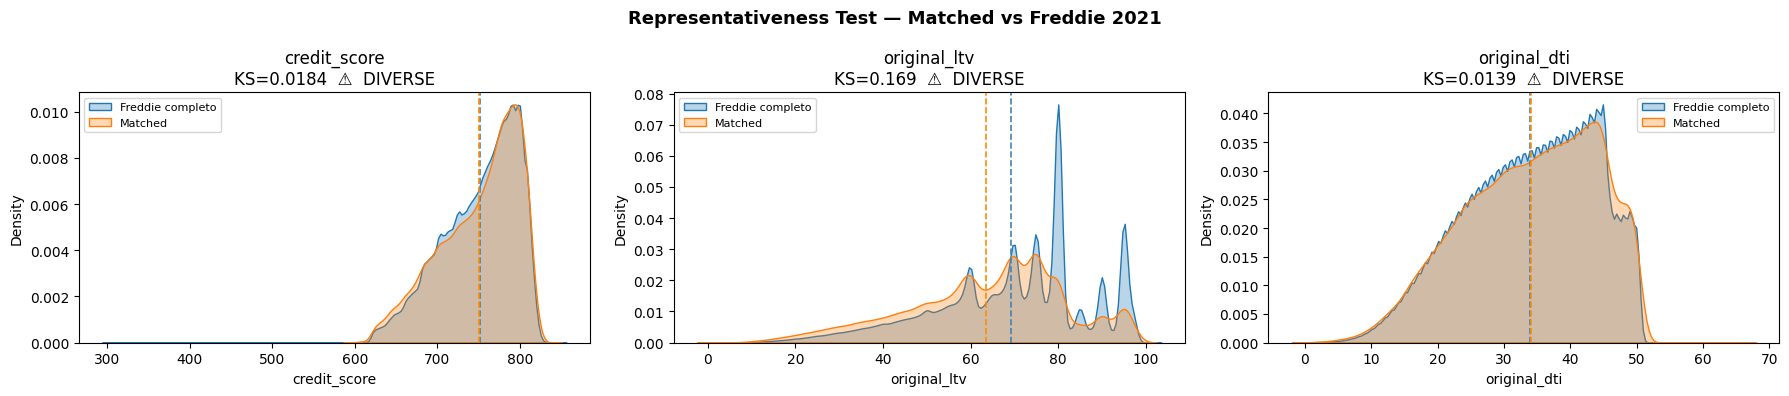

Grafico salvato: /content/drive/MyDrive/thesis_data/output/representativeness_2021.png

  BLOCCO 3 — CAMPIONE DI CONTROLLO HMDA (purchaser_type=3)
Campione HMDA di controllo: 1,045,586 righe

  BLOCCO 4 — DISTRIBUZIONE DEMOGRAFICA

Distribuzione etnica:
                                           HMDA (Freddie) %  Matched %  \
derived_race                                                             
White                                                 66.63      68.07   
Race Not Available                                    19.69      18.17   
Asian                                                  6.87       7.00   
Black or African American                              4.27       4.26   
Joint                                                  1.87       1.84   
American Indian or Alaska Native                       0.37       0.35   
Native Hawaiian or Other Pacific Islander              0.19       0.18   
2 or more minority races                               0.12       0.12   
Free F

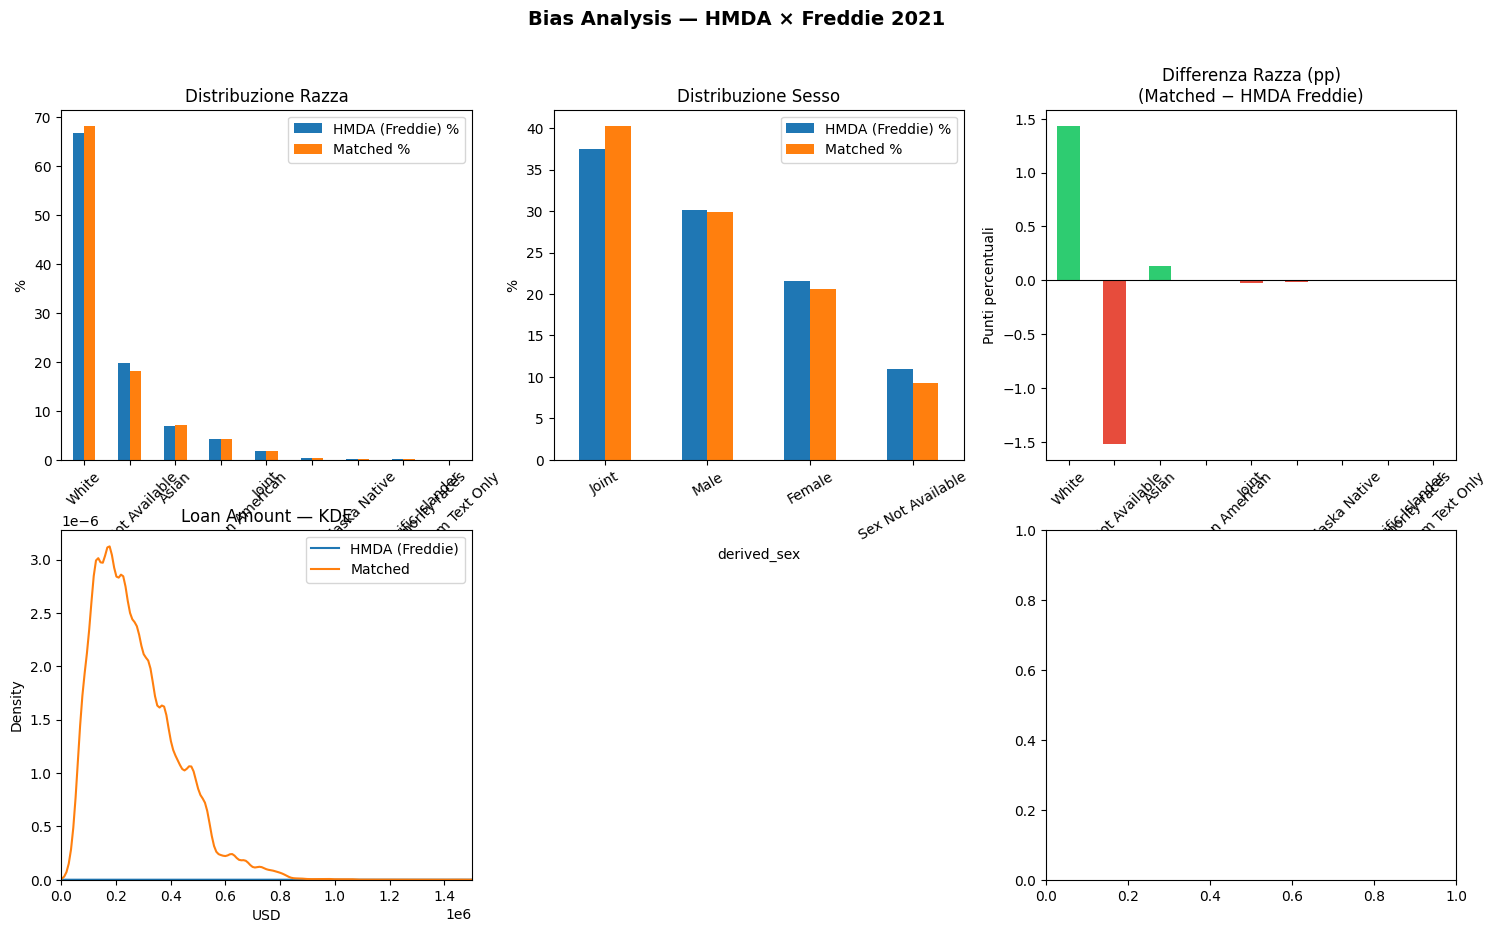

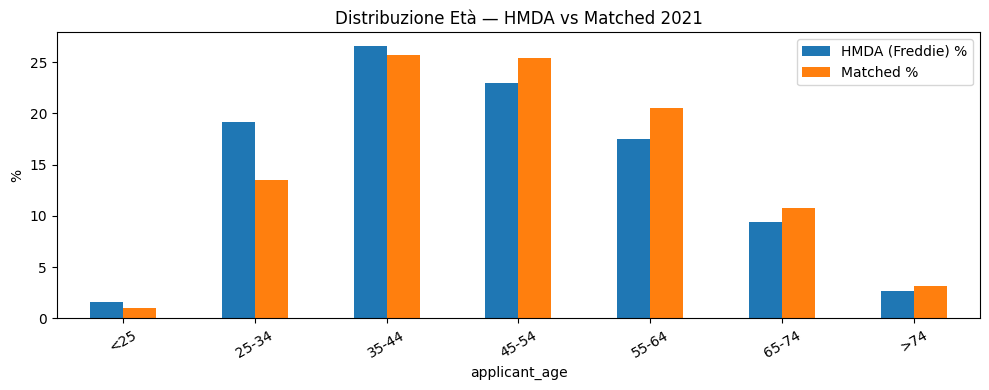

Grafico salvato: /content/drive/MyDrive/thesis_data/output/age_distribution_2021.png


<Figure size 640x480 with 0 Axes>

Grafico salvato: /content/drive/MyDrive/thesis_data/output/bias_analysis_2021.png


In [4]:
run_evaluation(2021)

Trovati 4 file zip per 2022:
  Estraggo historical_data_2022Q1.zip ... OK (90 MB)
  Estraggo historical_data_2022Q2.zip ... OK (68 MB)
  Estraggo historical_data_2022Q3.zip ... OK (53 MB)
  Estraggo historical_data_2022Q4.zip ... OK (35 MB)
  🗓️  ANNO IN ELABORAZIONE: 2022
  📄 matched_path : /content/drive/MyDrive/thesis_data/output/matched_2022.csv
  📄 hmda_path    : /content/drive/MyDrive/thesis_data/hmda/2022_public_lar_csv.csv
  📄 freddie_txts :
       → /content/freddie_local/historical_data_2022Q1.txt
       → /content/freddie_local/historical_data_2022Q2.txt
       → /content/freddie_local/historical_data_2022Q3.txt
       → /content/freddie_local/historical_data_2022Q4.txt
  historical_data_2022Q1.txt: 583,705 righe  (90 MB)
  historical_data_2022Q2.txt: 437,886 righe  (68 MB)
  historical_data_2022Q3.txt: 336,779 righe  (53 MB)
  historical_data_2022Q4.txt: 222,382 righe  (35 MB)
Totale caricato: 1,580,752 righe
Dopo dropna chiavi: 1,580,752 righe (rimossi 0)
RAM Freddie: 2073

,variable,mean_matched,mean_freddie,diff_mean,p10_matched,p10_freddie,p90_matched,p90_freddie,ks_stat,ks_p,flag
0,credit_score,741.99,743.73,-1.73,670.0,677.0,800.0,799.0,0.0236,1.65e-34,⚠️ DIVERSE
1,original_ltv,65.88,73.17,-7.29,38.0,46.0,94.0,95.0,0.2221,0.00e+00,⚠️ DIVERSE
2,original_dti,36.42,36.67,-0.24,23.0,23.0,48.0,48.0,0.0144,4.23e-13,⚠️ DIVERSE


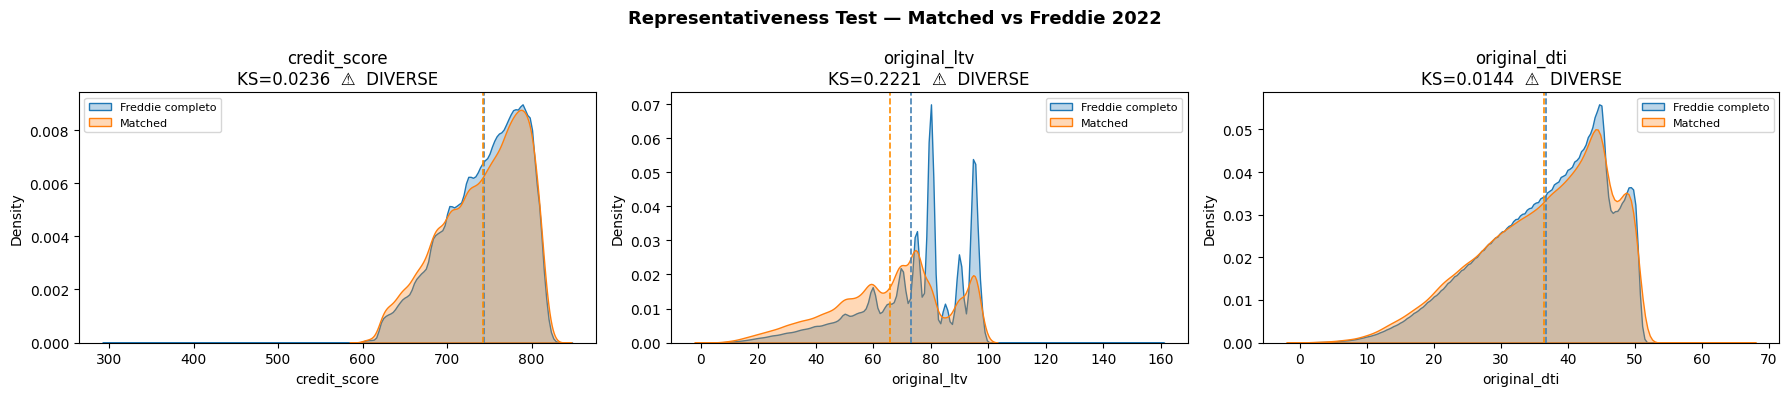

Grafico salvato: /content/drive/MyDrive/thesis_data/output/representativeness_2022.png

  BLOCCO 3 — CAMPIONE DI CONTROLLO HMDA (purchaser_type=3)
Campione HMDA di controllo: 1,012,897 righe

  BLOCCO 4 — DISTRIBUZIONE DEMOGRAFICA

Distribuzione etnica:
                                           HMDA (Freddie) %  Matched %  \
derived_race                                                             
White                                                 67.24      67.05   
Race Not Available                                    16.80      17.64   
Asian                                                  7.32       6.72   
Black or African American                              5.87       5.92   
Joint                                                  2.00       1.87   
American Indian or Alaska Native                       0.44       0.44   
Native Hawaiian or Other Pacific Islander              0.17       0.18   
2 or more minority races                               0.14       0.15   
Free F

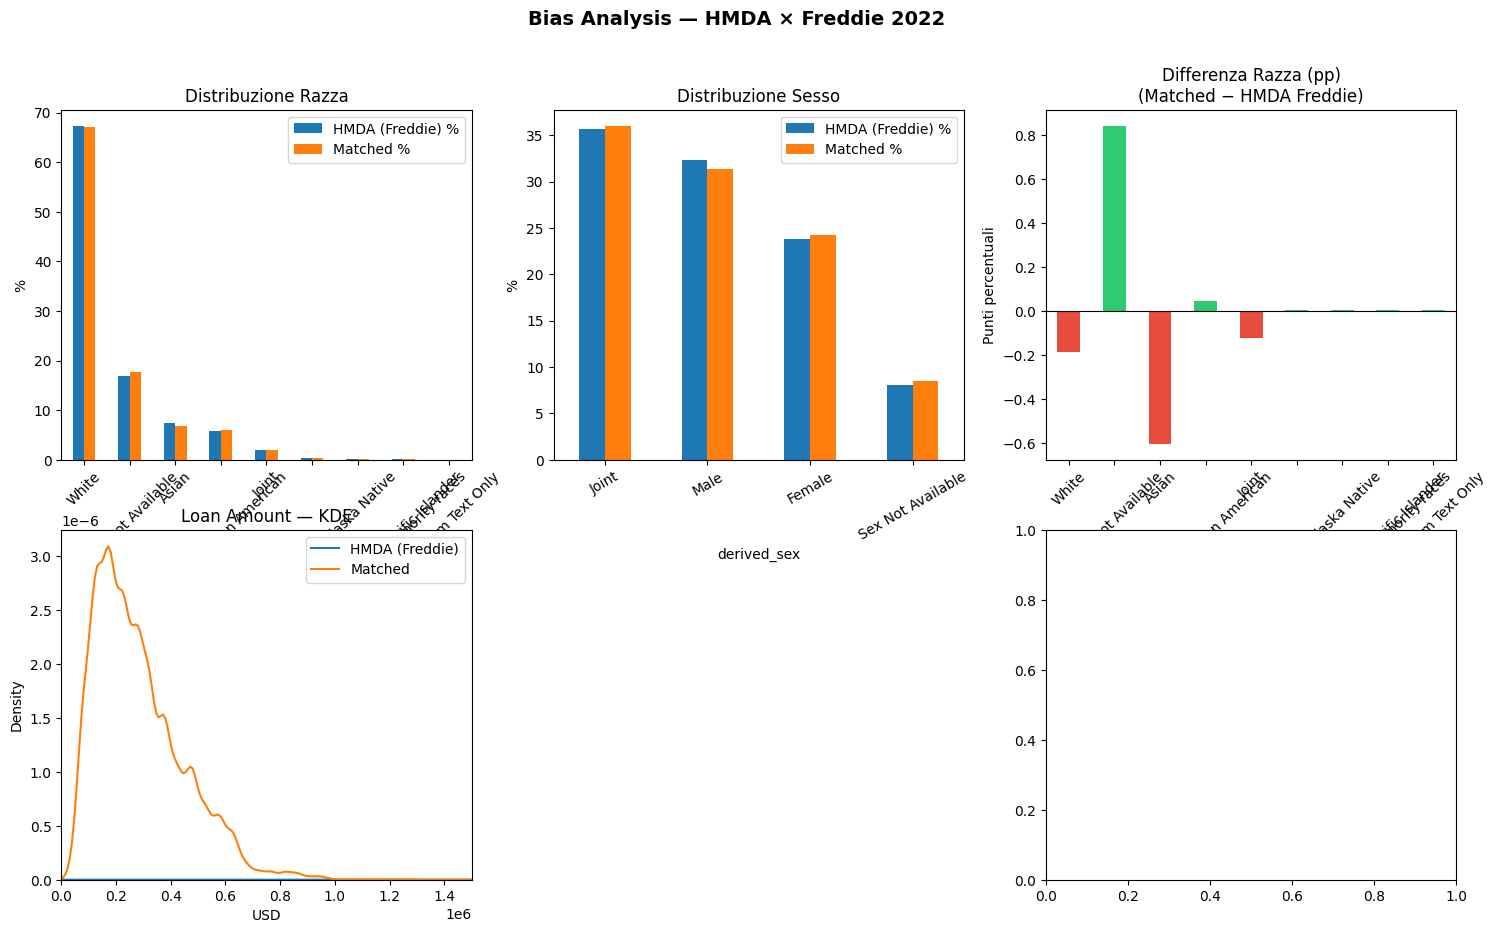

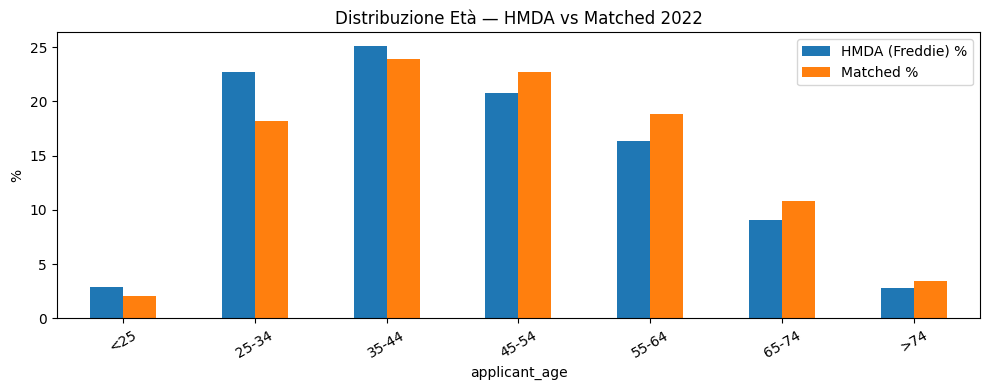

Grafico salvato: /content/drive/MyDrive/thesis_data/output/age_distribution_2022.png


<Figure size 640x480 with 0 Axes>

Grafico salvato: /content/drive/MyDrive/thesis_data/output/bias_analysis_2022.png


In [5]:
run_evaluation(2022)

Trovati 4 file zip per 2023:
  Estraggo historical_data_2023Q1.zip ... OK (29 MB)
  Estraggo historical_data_2023Q2.zip ... OK (43 MB)
  Estraggo historical_data_2023Q3.zip ... OK (41 MB)
  Estraggo historical_data_2023Q4.zip ... OK (32 MB)
  🗓️  ANNO IN ELABORAZIONE: 2023
  📄 matched_path : /content/drive/MyDrive/thesis_data/output/matched_2023.csv
  📄 hmda_path    : /content/drive/MyDrive/thesis_data/hmda/2023_public_lar_csv.csv
  📄 freddie_txts :
       → /content/freddie_local/historical_data_2023Q1.txt
       → /content/freddie_local/historical_data_2023Q2.txt
       → /content/freddie_local/historical_data_2023Q3.txt
       → /content/freddie_local/historical_data_2023Q4.txt
  historical_data_2023Q1.txt: 186,034 righe  (29 MB)
  historical_data_2023Q2.txt: 276,109 righe  (43 MB)
  historical_data_2023Q3.txt: 262,615 righe  (41 MB)
  historical_data_2023Q4.txt: 206,991 righe  (32 MB)
Totale caricato: 931,749 righe
Dopo dropna chiavi: 931,749 righe (rimossi 0)
RAM Freddie: 1222 MB


,variable,mean_matched,mean_freddie,diff_mean,p10_matched,p10_freddie,p90_matched,p90_freddie,ks_stat,ks_p,flag
0,credit_score,749.22,749.79,-0.57,681.0,686.0,802.0,801.0,0.0201,5.36e-13,⚠️ DIVERSE
1,original_ltv,66.55,75.68,-9.13,34.0,46.0,95.0,95.0,0.2590,0.00e+00,⚠️ DIVERSE
2,original_dti,37.53,38.12,-0.59,23.0,25.0,49.0,49.0,0.0284,1.51e-25,⚠️ DIVERSE


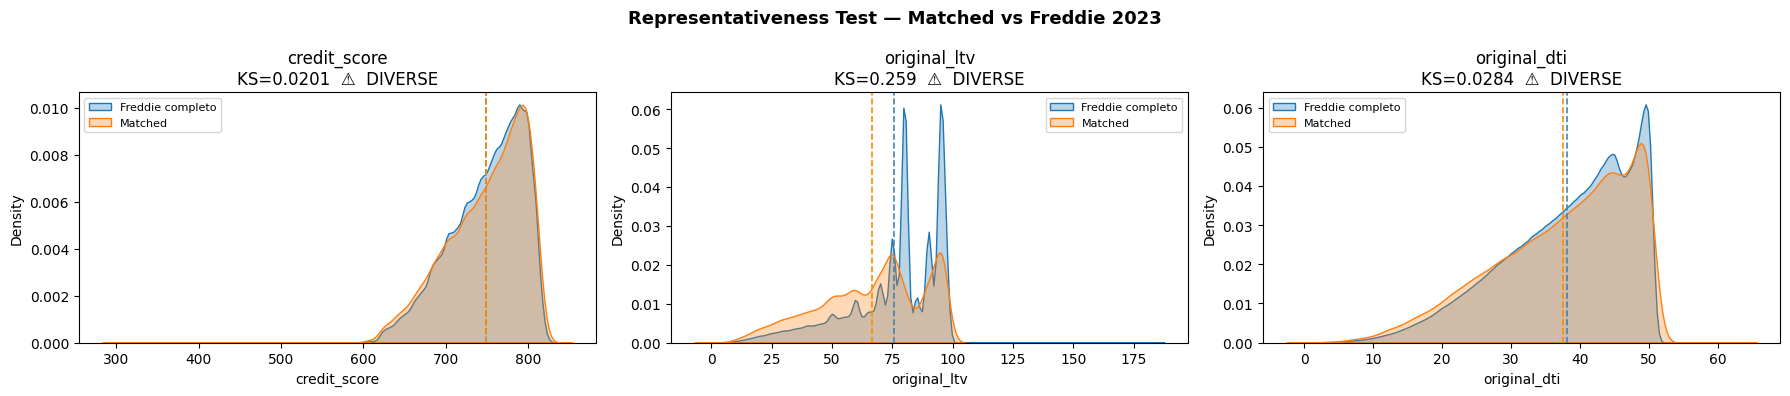

Grafico salvato: /content/drive/MyDrive/thesis_data/output/representativeness_2023.png

  BLOCCO 3 — CAMPIONE DI CONTROLLO HMDA (purchaser_type=3)
Campione HMDA di controllo: 580,677 righe

  BLOCCO 4 — DISTRIBUZIONE DEMOGRAFICA

Distribuzione etnica:
                                           HMDA (Freddie) %  Matched %  \
derived_race                                                             
White                                                 67.52      67.61   
Race Not Available                                    15.08      15.14   
Asian                                                  8.69       8.18   
Black or African American                              5.74       6.04   
Joint                                                  2.18       2.17   
American Indian or Alaska Native                       0.46       0.47   
Native Hawaiian or Other Pacific Islander              0.15       0.19   
2 or more minority races                               0.15       0.17   
Free For

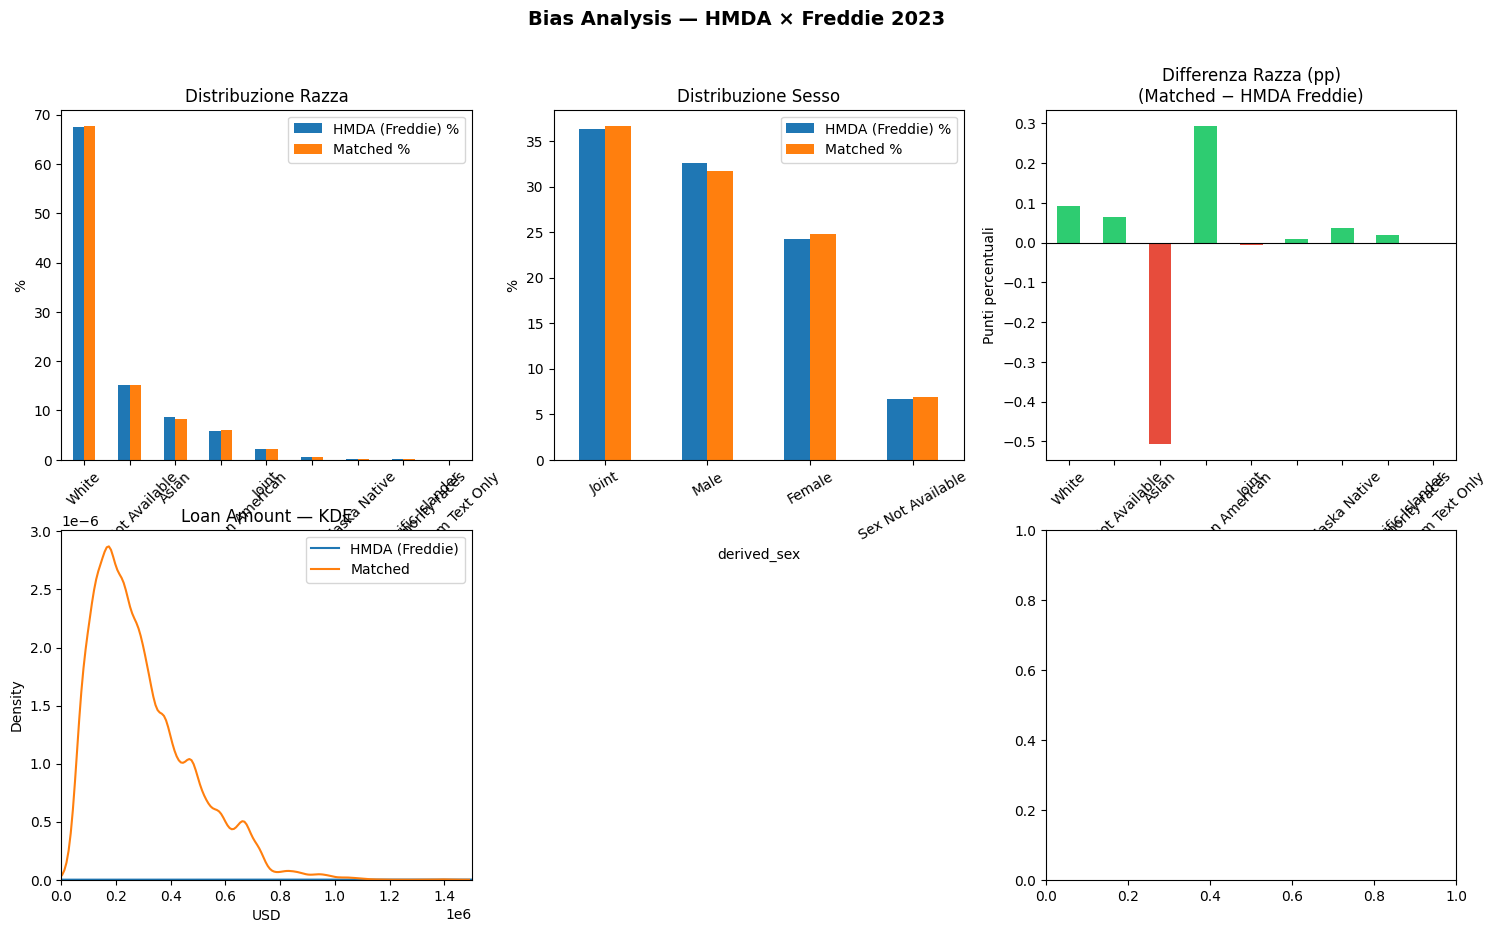

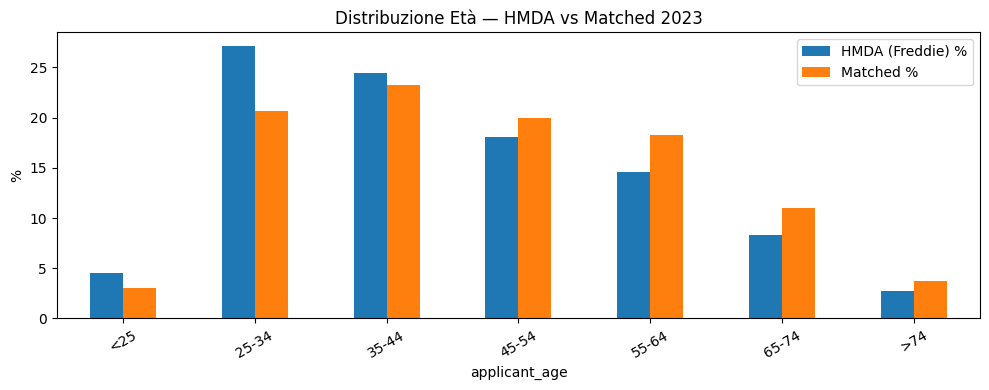

Grafico salvato: /content/drive/MyDrive/thesis_data/output/age_distribution_2023.png


<Figure size 640x480 with 0 Axes>

Grafico salvato: /content/drive/MyDrive/thesis_data/output/bias_analysis_2023.png


In [6]:
run_evaluation(2023)

Trovati 4 file zip per 2024:
  Estraggo historical_data_2024Q1.zip ... OK (34 MB)
  Estraggo historical_data_2024Q2.zip ... OK (39 MB)
  Estraggo historical_data_2024Q3.zip ... OK (46 MB)
  Estraggo historical_data_2024Q4.zip ... OK (44 MB)
  🗓️  ANNO IN ELABORAZIONE: 2024
  📄 matched_path : /content/drive/MyDrive/thesis_data/output/matched_2024.csv
  📄 hmda_path    : /content/drive/MyDrive/thesis_data/hmda/2024_public_lar_csv.csv
  📄 freddie_txts :
       → /content/freddie_local/historical_data_2024Q1.txt
       → /content/freddie_local/historical_data_2024Q2.txt
       → /content/freddie_local/historical_data_2024Q3.txt
       → /content/freddie_local/historical_data_2024Q4.txt
  historical_data_2024Q1.txt: 215,022 righe  (34 MB)
  historical_data_2024Q2.txt: 255,625 righe  (39 MB)
  historical_data_2024Q3.txt: 296,015 righe  (46 MB)
  historical_data_2024Q4.txt: 281,745 righe  (44 MB)
Totale caricato: 1,048,407 righe
Dopo dropna chiavi: 1,048,407 righe (rimossi 0)
RAM Freddie: 1375

,variable,mean_matched,mean_freddie,diff_mean,p10_matched,p10_freddie,p90_matched,p90_freddie,ks_stat,ks_p,flag
0,credit_score,752.81,752.65,0.16,683.0,686.0,804.0,802.0,0.0172,1.13e-10,⚠️ DIVERSE
1,original_ltv,65.30,74.72,-9.43,33.0,45.0,95.0,95.0,0.2629,0.00e+00,⚠️ DIVERSE
2,original_dti,37.04,37.86,-0.82,23.0,24.0,49.0,49.0,0.0322,2.62e-36,⚠️ DIVERSE


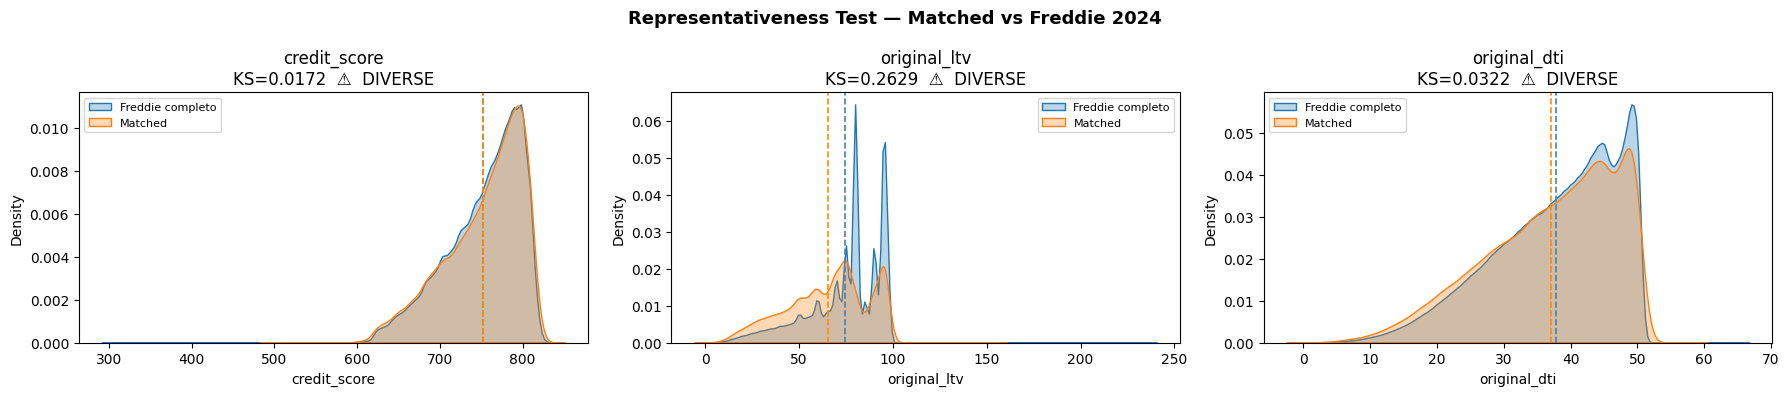

Grafico salvato: /content/drive/MyDrive/thesis_data/output/representativeness_2024.png

  BLOCCO 3 — CAMPIONE DI CONTROLLO HMDA (purchaser_type=3)
Campione HMDA di controllo: 647,448 righe

  BLOCCO 4 — DISTRIBUZIONE DEMOGRAFICA

Distribuzione etnica:
                                           HMDA (Freddie) %  Matched %  \
derived_race                                                             
White                                                 68.91      68.58   
Race Not Available                                    13.84      14.24   
Asian                                                  9.09       9.04   
Black or African American                              5.06       5.02   
Joint                                                  2.30       2.40   
American Indian or Alaska Native                       0.46       0.39   
2 or more minority races                               0.19       0.16   
Native Hawaiian or Other Pacific Islander              0.13       0.14   
Free For

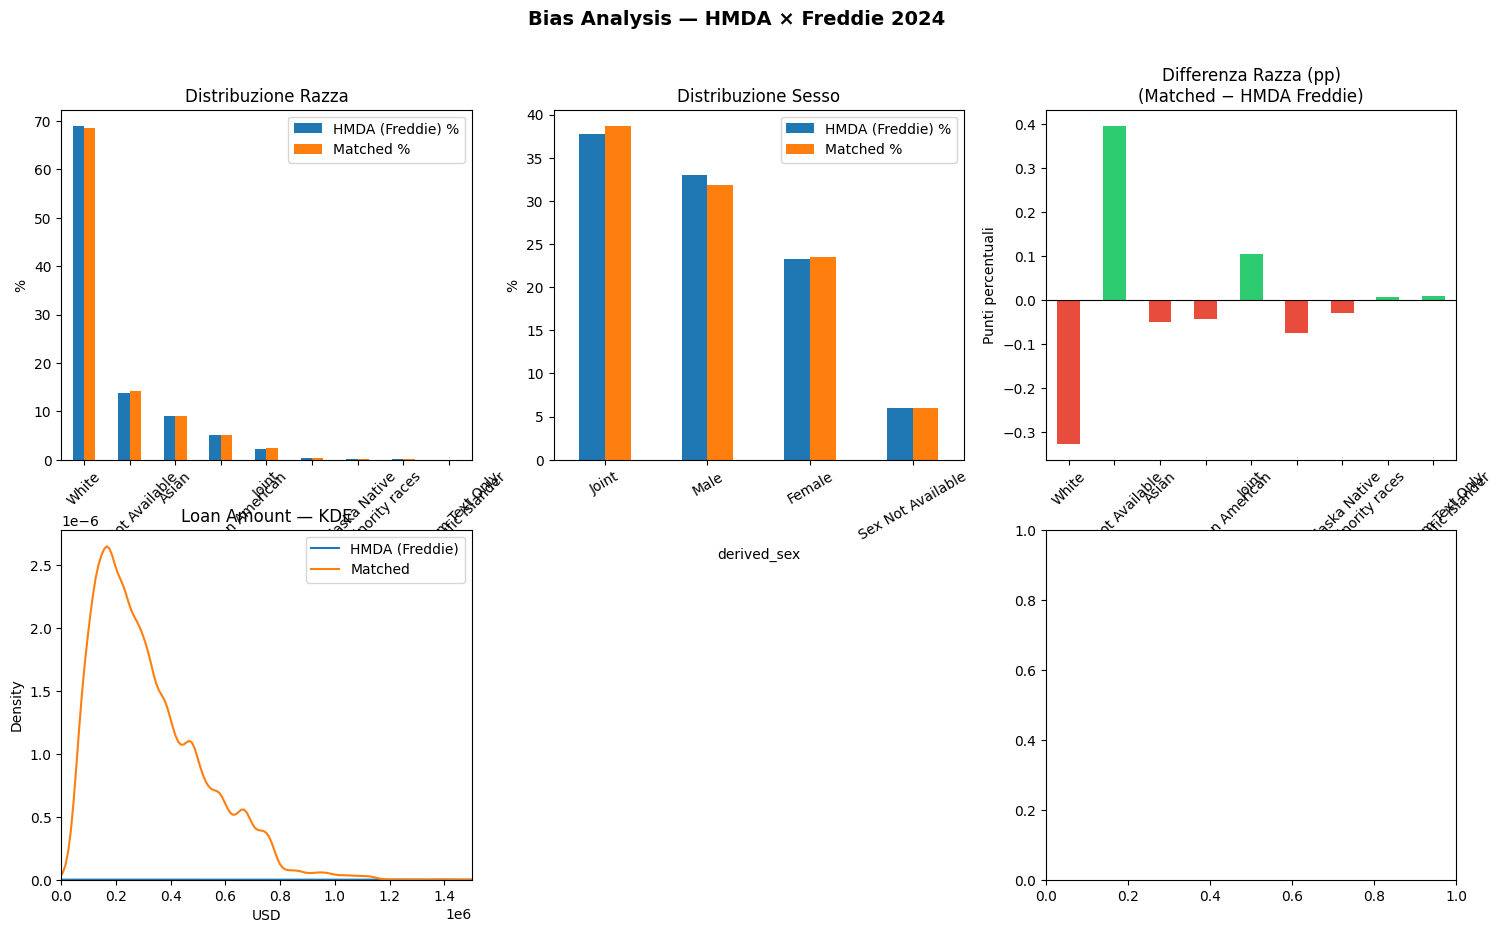

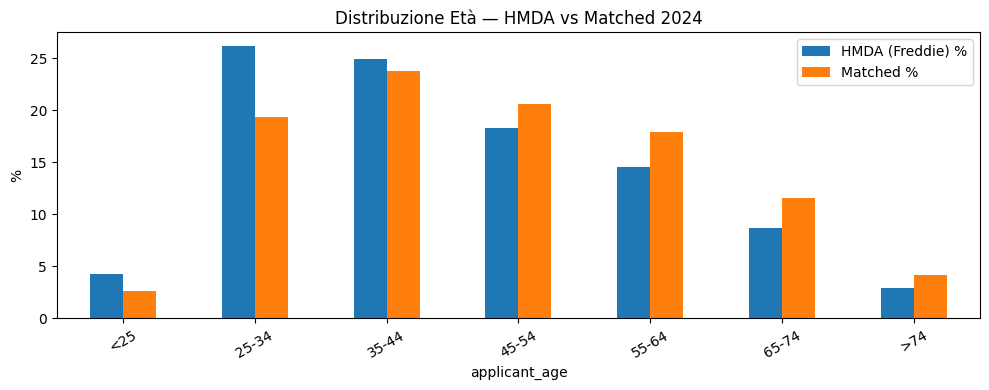

Grafico salvato: /content/drive/MyDrive/thesis_data/output/age_distribution_2024.png


<Figure size 640x480 with 0 Axes>

Grafico salvato: /content/drive/MyDrive/thesis_data/output/bias_analysis_2024.png


In [7]:
run_evaluation(2024)

In [10]:
import subprocess

NOTEBOOK = "/content/checMatchDistribuzioni.ipynb"  # ← adatta il percorso se è in una sottocartella
OUTPUT   = "/content/drive/MyDrive/thesis_data/output"

subprocess.run(["pip", "install", "nbconvert", "-q"])

subprocess.run([
    "jupyter", "nbconvert", "--to", "html",
    "--output-dir", OUTPUT,
    NOTEBOOK
], check=True)

print(f"✅ HTML salvato in: {OUTPUT}/checMatchDistribuzioni.html")

✅ HTML salvato in: /content/drive/MyDrive/thesis_data/output/checMatchDistribuzioni.html


In [9]:
import subprocess

# Prima troviamo il path esatto
result = subprocess.run(
    ["find", "/content/drive/MyDrive", "-name", "checMatchDistribuzioni.ipynb"],
    capture_output=True, text=True
)
print(result.stdout)

/content/drive/MyDrive/Colab Notebooks/checMatchDistribuzioni.ipynb

